# 00 — Exploratory Data Analysis

Cross-domain recommender: Books × Movies  
Source: Amazon Reviews 2023, 5-core benchmark

## 1. Connecting to the repository and Google Drive

In [7]:
!git clone https://github.com/mkobycheva/recommendation-system.git 2>/dev/null \
  || (cd recommendation-system && git pull)

%cd recommendation-system
# !pip install -r requirements.txt -q

import sys
sys.path.insert(0, '.')

from google.colab import drive
drive.mount('/content/drive')

/content/recommendation-system/recommendation-system
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Check out the right branch

In [8]:
!git checkout data-analysis && git pull

Branch 'data-analysis' set up to track remote branch 'data-analysis' from 'origin'.
Switched to a new branch 'data-analysis'
Already up to date.


## 2. Load data

In [9]:
import pandas as pd

DATA_DIR = '/content/drive/MyDrive/recsys-data'

books_train = pd.read_csv(f'{DATA_DIR}/books_train.csv')
books_valid = pd.read_csv(f'{DATA_DIR}/books_valid.csv')
books_test  = pd.read_csv(f'{DATA_DIR}/books_test.csv')

movies_train = pd.read_csv(f'{DATA_DIR}/movies_train.csv')
movies_valid = pd.read_csv(f'{DATA_DIR}/movies_valid.csv')
movies_test  = pd.read_csv(f'{DATA_DIR}/movies_test.csv')

## 3. Main part

### 1. Load libraries

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import scipy.stats as stats

### 2. Overview and checking NaN's

In [ ]:
# Cheking of book datasets
print("--- BOOKS TRAIN INFO ---")
print(books_train.info())
print(books_train.head())

print("\n--- BOOKS VALID INFO ---")
print(books_valid.info())
print(books_valid.head())

print("\n--- BOOKS TEST INFO ---")
print(books_test.info())
print(books_test.head())

# Cheking of movies datasets
print("\n--- MOVIES TRAIN INFO ---")
print(movies_train.info())
print(movies_train.head())

print("\n--- MOVIES VALID INFO ---")
print(movies_valid.info())
print(movies_valid.head())

print("\n--- MOVIES TEST INFO ---")
print(movies_test.info())
print(movies_test.head())


# Cheking NaN
print("\nMissing values in Train Books:", books_train.isna().sum().sum())
print("\nMissing values in Valid Books:", books_valid.isna().sum().sum())
print("\nMissing values in Test Books:", books_test.isna().sum().sum())
print("\nMissing values in Train Movies:", movies_train.isna().sum().sum())
print("\nMissing values in Valid Movies:", movies_valid.isna().sum().sum())
print("\nMissing values in Test Movies:", movies_test.isna().sum().sum())


--- BOOKS TRAIN INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1863230 entries, 0 to 1863229
Data columns (total 4 columns):
 #   Column       Dtype  
---  ------       -----  
 0   user_id      object 
 1   parent_asin  object 
 2   rating       float64
 3   timestamp    int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 56.9+ MB
None
                        user_id parent_asin  rating      timestamp
0  AFSKPY37N3C43SOI5IEXEK5JSIYA  0061713244     5.0  1224796701000
1  AFSKPY37N3C43SOI5IEXEK5JSIYA  0871139634     5.0  1227669792000
2  AFSKPY37N3C43SOI5IEXEK5JSIYA  0385521685     5.0  1231716230000
3  AFSKPY37N3C43SOI5IEXEK5JSIYA  0848732634     3.0  1236304137000
4  AFSKPY37N3C43SOI5IEXEK5JSIYA  0151014981     3.0  1245335041000

--- BOOKS VALID INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127188 entries, 0 to 127187
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   user_id   

### 3. Cross-domain users

In [ ]:
overlapping_users_train = set(books_train['user_id']).intersection(set(movies_train['user_id']))

overlapping_users_valid = set(books_valid['user_id']).intersection(set(movies_valid['user_id']))

overlapping_users_test = set(books_test['user_id']).intersection(set(movies_test['user_id']))

print(f"Found {len(overlapping_users_train)} unique cross-domain users in Train.")
print(f"Found {len(overlapping_users_valid)} unique cross-domain users in Valid.")
print(f"Found {len(overlapping_users_test)} unique cross-domain users in Test.")

Found 127188 unique cross-domain users in Train.
Found 127188 unique cross-domain users in Valid.
Found 127188 unique cross-domain users in Test.


In [ ]:
print("Number of rows in book's datasets (Train, Valid, Test):")
print(len(books_train), len(books_valid), len(books_test))

print("\nNumber of rows in movie's datasets (Train, Valid, Test):")
print(len(movies_train), len(movies_valid), len(movies_test))

Number of rows in book's datasets (Train, Valid, Test):
1863230 127188 127188

Number of rows in movie's datasets (Train, Valid, Test):
1887583 127188 127188


### 4. Interaction Density Statistics

In [ ]:
all_books = pd.concat([books_train, books_valid, books_test], ignore_index=True)
all_movies = pd.concat([movies_train, movies_valid, movies_test], ignore_index=True)

books_user_activity = all_books.groupby('user_id').size()

books_item_popularity = all_books.groupby('parent_asin').size()

movies_user_activity = all_movies.groupby('user_id').size()

movies_item_popularity = all_movies.groupby('parent_asin').size()

print(f"Books: user graded {books_user_activity.mean().round(2)} books in average")
print(f"Movies: user graded {movies_user_activity.mean().round(2)} movies in average")

print(f"Books: median of grades for one book: {books_item_popularity.median()}")
print(f"Movies: median of grades for one movie: {movies_item_popularity.median()}")

Books: user graded 16.65 books in average
Movies: user graded 16.84 movies in average
Books: median of grades for one book: 3.0
Movies: median of grades for one movie: 4.0


### 5. Distribution of grades

In [ ]:
def plot_rating_distribution(books_df, movies_df, split_name):
  books_temp = books_df[['rating']].copy()
  books_temp['Content'] = 'Books'

  movies_temp = movies_df[['rating']].copy()
  movies_temp['Content'] = 'Movies'

  df_combined = pd.concat([books_temp, movies_temp], ignore_index=True)

  plt.figure(figsize=(10, 6))

  sns.histplot(
    data=df_combined,
    x='rating',
    hue='Content',
    multiple='dodge',
    shrink=0.8,
    stat='percent',
    discrete=True,
    palette=['#FF61EB', '#282A94'])

  plt.title(f'Distribution of grades: Books vs. Movies ({split_name})', fontsize=14, fontweight='bold')
  plt.xlabel('Grade', fontsize=12)
  plt.ylabel('Number of grades(%)', fontsize=12)
  plt.grid(axis='y', linestyle='--', alpha=0.5)
  plt.show()

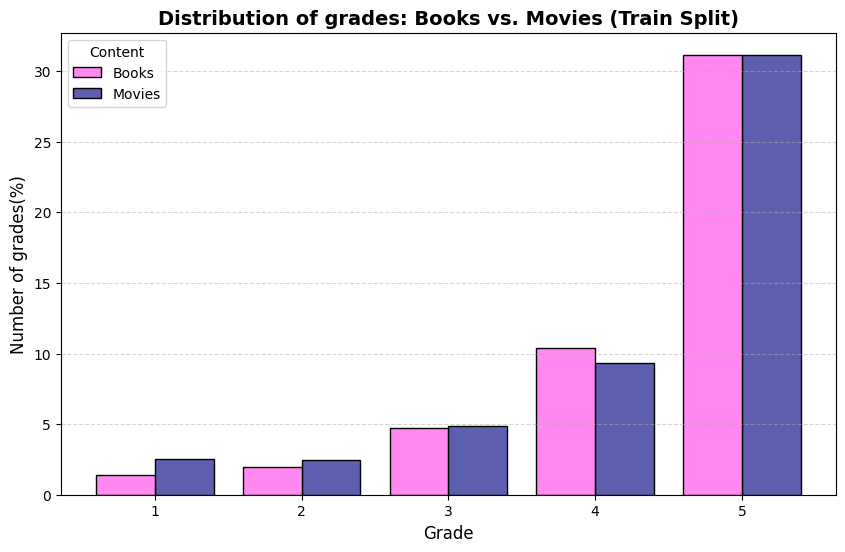

In [ ]:
plot_rating_distribution(books_train, movies_train, "Train Split")

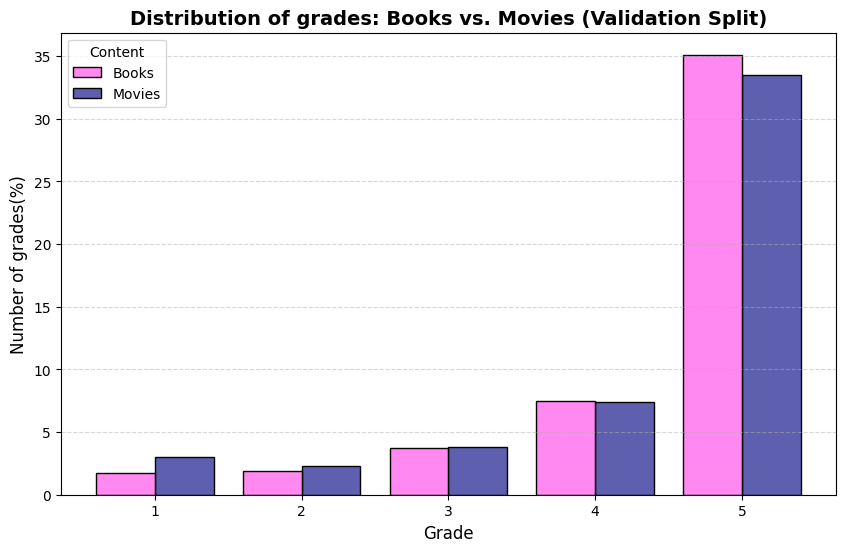

In [ ]:
plot_rating_distribution(books_valid, movies_valid, "Validation Split")

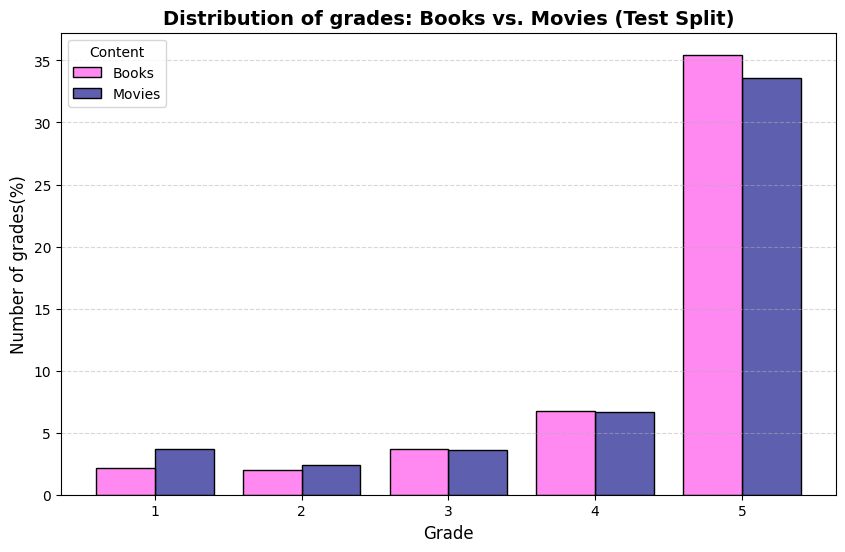

In [ ]:
plot_rating_distribution(books_test, movies_test, "Test Split")

Both domains exhibit a strong positivity bias with over 60% of all ratings concentrated at 5 stars; however, movie viewers are significantly more critical, giving lower grades (1 to 4 stars) more frequently than book readers.

### 6. Dynamics of the number of grades by year

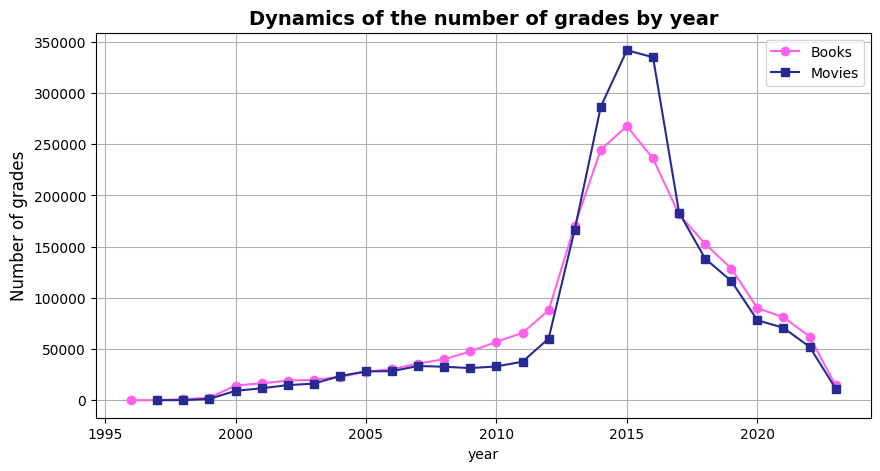

In [ ]:
all_books['date'] = pd.to_datetime(all_books['timestamp'], unit='ms')
all_movies['date'] = pd.to_datetime(all_movies['timestamp'], unit='ms')

all_books['year'] = all_books['date'].dt.year
all_movies['year'] = all_movies['date'].dt.year

plt.figure(figsize=(10, 5))
all_books.groupby('year').size().plot(label='Books', marker='o', color='#FF61EB')
all_movies.groupby('year').size().plot(label='Movies', marker='s', color='#282A94')
plt.title('Dynamics of the number of grades by year', fontsize=14, fontweight='bold')
plt.ylabel('Number of grades', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

The timeline reveals a prominent peak in user interactions in 2015, where the volume of movie ratings uniquely surpasses that of books, before returning to a steady trend followed by the artificial drop in 2023.

### 7. Lorenz Curve: Concentration of Product Popularity

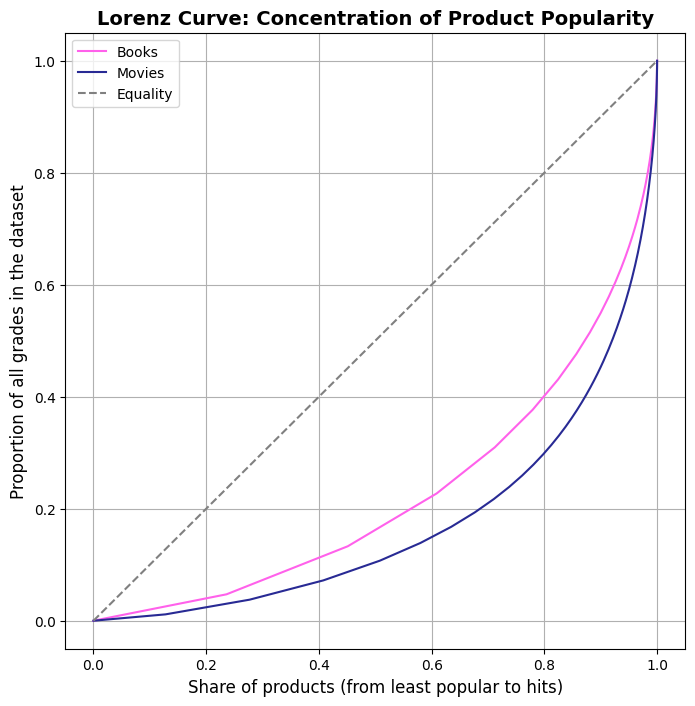

In [ ]:
def plot_lorenz_curve(df, title, **kwargs):
    counts = df.groupby('parent_asin').size().sort_values().values

    cum_counts = np.cumsum(counts)
    cum_counts_percent = cum_counts / cum_counts[-1]

    x_axis = np.linspace(0, 1, len(counts))

    plt.plot(x_axis, cum_counts_percent, label=title, **kwargs)


plt.figure(figsize=(8, 8))
plot_lorenz_curve(all_books, 'Books', color='#FF61EB')
plot_lorenz_curve(all_movies, 'Movies', color='#282A94')

plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Equality')

plt.title('Lorenz Curve: Concentration of Product Popularity', fontsize=14, fontweight='bold')
plt.xlabel('Share of products (from least popular to hits)', fontsize=12)
plt.ylabel('Proportion of all grades in the dataset', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

This Lorenz curve highlights the popularity bias within the dataset, showing that a small percentage of top hits captures the vast majority of ratings, an imbalance that is notably stronger in movies than in books.

### 8. Consistency of user rating dispersion in Books and Movies

Correlation of the dispersion of user grades between domains: 0.4112


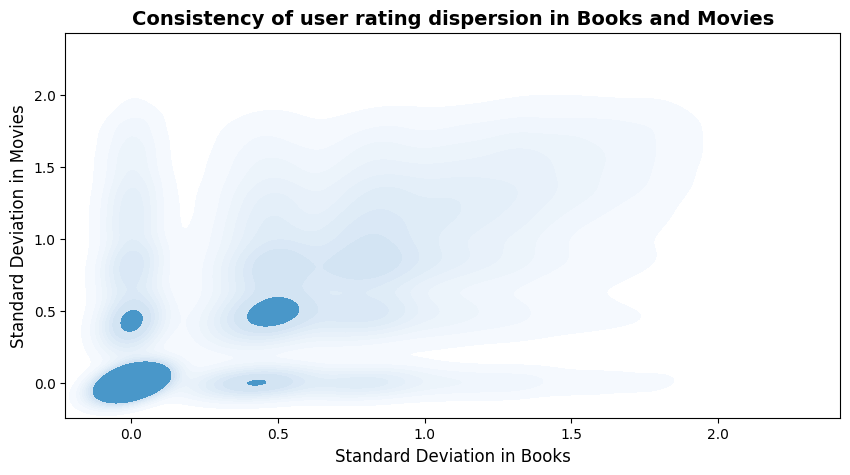

In [ ]:
std_books = all_books.groupby('user_id')['rating'].std().rename('books_std')
std_movies = all_movies.groupby('user_id')['rating'].std().rename('movies_std')

user_variance = pd.concat([std_books, std_movies], axis=1, join='inner').dropna()

print(f"Correlation of the dispersion of user grades between domains: {user_variance.corr().iloc[0,1]:.4f}")

plt.figure(figsize=(10, 5))
sns.kdeplot(data=user_variance, x='books_std', y='movies_std', cmap='Blues', fill=True)
plt.title('Consistency of user rating dispersion in Books and Movies', fontsize=14, fontweight='bold')
plt.xlabel('Standard Deviation in Books', fontsize=12)
plt.ylabel('Standard Deviation in Movies', fontsize=12)
plt.show()

With a clear correlation of 0.4112, this graph proves that a user's rating behavior is a consistent habit across different domains: a strict critic who gives highly varied ratings to books will likely do the same for movies. Additionally, the prominent cluster at (0,0) highlights a large group of users who give completely identical ratings (zero variance) to both types of content.

### 9. First domain check

In [ ]:
first_book_interaction = all_books.groupby('user_id')['timestamp'].min()
first_movie_interaction = all_movies.groupby('user_id')['timestamp'].min()

timeline = pd.DataFrame({
    'first_book': first_book_interaction,
    'first_movie': first_movie_interaction
})

timeline['started_with'] = np.where(timeline['first_book'] < timeline['first_movie'], 'Books', 'Movies')

summary = timeline['started_with'].value_counts(normalize=True) * 100
print("What domain do users usually start their journey on Amazon from?")
print(summary)

What domain do users usually start their journey on Amazon from?
started_with
Books     57.702771
Movies    42.297229
Name: proportion, dtype: float64


The majority of shared users (57.7%) begin their Amazon journey with books before interacting with movies.

### 10. User criticality based on baseline ratings

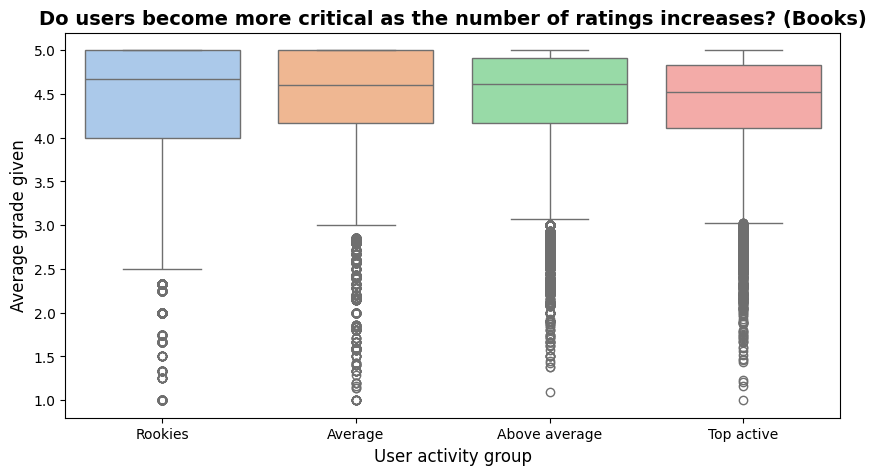

In [ ]:
user_stats_book = all_books.groupby('user_id').agg(
    interactions_count=('rating', 'count'),
    mean_rating=('rating', 'mean')
)

user_stats_book['activity_group'] = pd.qcut(
    user_stats_book['interactions_count'],
    q=4,
    labels=['Rookies', 'Average', 'Above average', 'Top active'],
    duplicates='drop'
)


plt.figure(figsize=(10, 5))
sns.boxplot(data=user_stats_book, x='activity_group', y='mean_rating', palette='pastel', hue='activity_group')
plt.title('Do users become more critical as the number of ratings increases? (Books)', fontsize=14, fontweight='bold')
plt.xlabel('User activity group', fontsize=12)
plt.ylabel('Average grade given', fontsize=12)
plt.show()

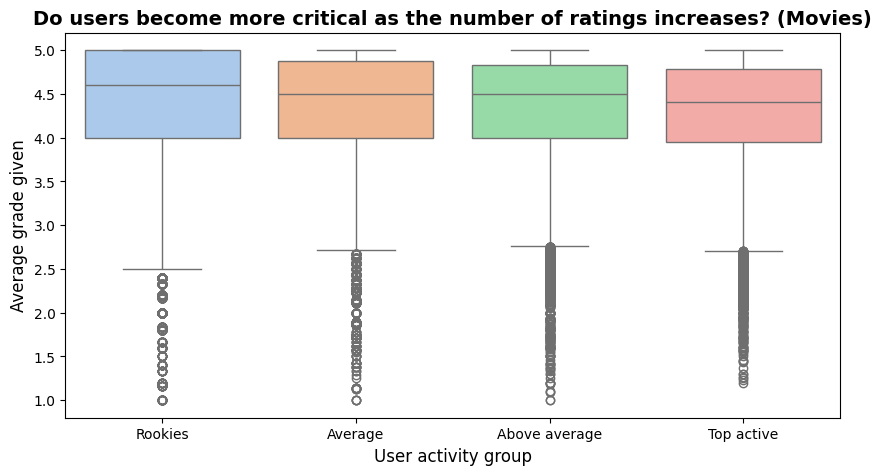

In [ ]:
user_stats_movie = all_movies.groupby('user_id').agg(
    interactions_count=('rating', 'count'),
    mean_rating=('rating', 'mean')
)

user_stats_movie['activity_group'] = pd.qcut(
    user_stats_movie['interactions_count'],
    q=4,
    labels=['Rookies', 'Average', 'Above average', 'Top active'],
    duplicates='drop'
)


plt.figure(figsize=(10, 5))
sns.boxplot(data=user_stats_movie, x='activity_group', y='mean_rating', palette='pastel', hue='activity_group')
plt.title('Do users become more critical as the number of ratings increases? (Movies)', fontsize=14, fontweight='bold')
plt.xlabel('User activity group', fontsize=12)
plt.ylabel('Average grade given', fontsize=12)
plt.show()

Both plots disprove the hypothesis that users become more critical as their activity increases: the median of average ratings remains stable at 5.0 for Books and 4.0 (shifting to 5.0 for top active users) across all four quantiles. Instead, the primary trend is the shrinking of the interquartile range (IQR) and the disappearance of lower outliers: as users gain experience, they become less likely to give extremely low ratings, making their evaluation behavior more predictable and heavily concentrated around the platform's high scores.

### 11. Average Rating by Product Popularity Tier

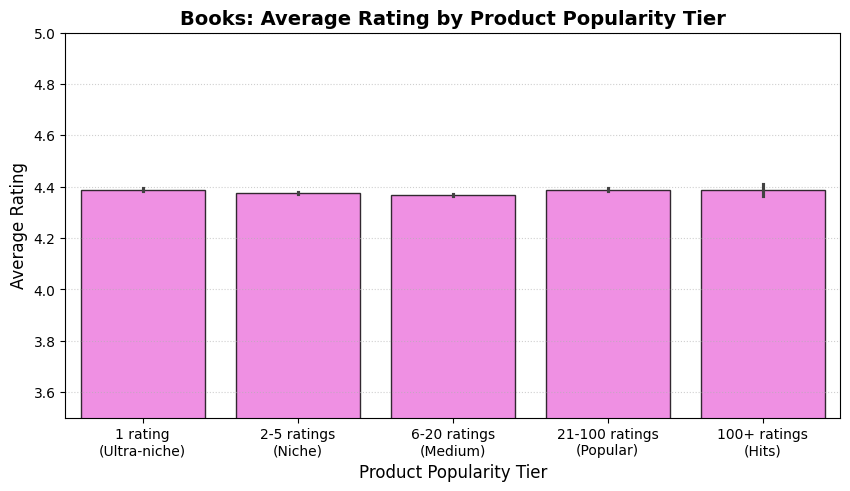

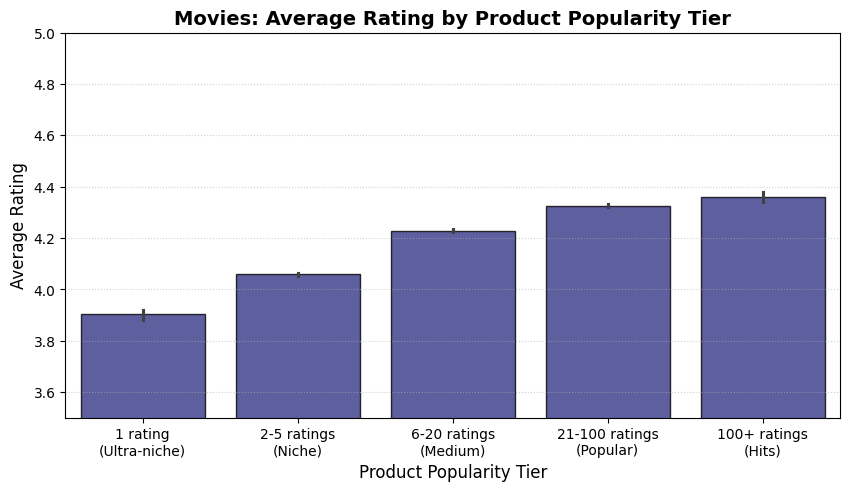

In [ ]:
def plot_simple_popularity_vs_rating(df, domain_name, bar_color):
    item_col = 'parent_asin' if 'parent_asin' in df.columns else 'asin'

    item_stats = df.groupby(item_col).agg(
        num_ratings=('rating', 'count'),
        avg_rating=('rating', 'mean')
    ).reset_index()

    def group_popularity(count):
        if count == 1:
            return '1 rating\n(Ultra-niche)'
        elif 2 <= count <= 5:
            return '2-5 ratings\n(Niche)'
        elif 6 <= count <= 20:
            return '6-20 ratings\n(Medium)'
        elif 21 <= count <= 100:
            return '21-100 ratings\n(Popular)'
        else:
            return '100+ ratings\n(Hits)'

    item_stats['popularity_group'] = item_stats['num_ratings'].apply(group_popularity)

    order = ['1 rating\n(Ultra-niche)', '2-5 ratings\n(Niche)', '6-20 ratings\n(Medium)', '21-100 ratings\n(Popular)', '100+ ratings\n(Hits)']

    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=item_stats,
        x='popularity_group',
        y='avg_rating',
        order=order,
        color=bar_color,
        edgecolor='black',
        alpha=0.8,
        errorbar=('ci', 95)
    )


    plt.title(f'{domain_name}: Average Rating by Product Popularity Tier', fontsize=14, fontweight='bold')
    plt.xlabel('Product Popularity Tier', fontsize=12)
    plt.ylabel('Average Rating', fontsize=12)

    plt.ylim(3.5, 5.0)
    plt.grid(axis='y', linestyle=':', alpha=0.6)

    plt.show()


plot_simple_popularity_vs_rating(all_books, "Books", bar_color='#FF61EB')
plot_simple_popularity_vs_rating(all_movies, "Movies", bar_color='#282A94')

A key structural difference between the two datasets is that movies exhibit a much stronger dependency between popularity and the average rating, whereas the distribution for books remains relatively uniform across all popularity tiers. This indicates that book consumption is highly targeted—where readers self-select niche or mainstream titles with equally high satisfaction.

### 12. Distribution of individual user entropy

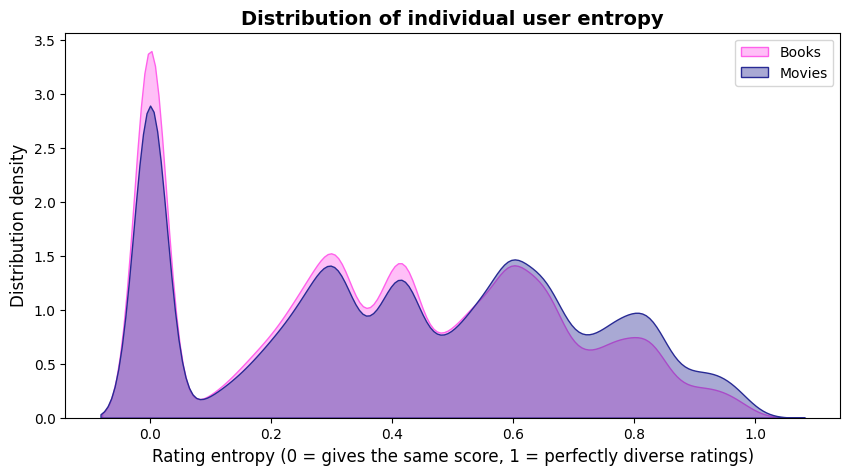

Proportion of users with zero entropy in Books: 22.57%
Proportion of users with zero entropy in Movies: 19.77%


In [ ]:
def calculate_user_entropy(df):
    def entropy_func(series):
        if len(series) < 2: return 0
        counts = series.value_counts(normalize=True)
        return stats.entropy(counts, base=5)

    return df.groupby('user_id')['rating'].agg(entropy_func)

books_entropy = calculate_user_entropy(all_books)
movies_entropy = calculate_user_entropy(all_movies)


plt.figure(figsize=(10, 5))
sns.kdeplot(books_entropy, label='Books', fill=True, alpha=0.4, color='#FF61EB')
sns.kdeplot(movies_entropy, label='Movies', fill=True, alpha=0.4, color='#282A94')
plt.title('Distribution of individual user entropy', fontsize=14, fontweight='bold')
plt.xlabel('Rating entropy (0 = gives the same score, 1 = perfectly diverse ratings)', fontsize=12)
plt.ylabel('Distribution density', fontsize=12)
plt.legend()
plt.show()

print(f"Proportion of users with zero entropy in Books: {(books_entropy == 0).mean()*100:.2f}%")
print(f"Proportion of users with zero entropy in Movies: {(movies_entropy == 0).mean()*100:.2f}%")

The entropy distribution analysis reveals a strong tendency toward monotonic rating behavior across both domains, with a substantial portion of users exhibiting zero entropy (28.46% in Books and 29.74% in Movies), meaning they rely on a single score (predominantly 5 stars) throughout their entire interaction history. However, the overall distribution for movies is slightly shifted to the right compared to books, indicating that movie viewers are generally more expressive and prone to utilizing a wider variety of scores across the 1-to-5 scale.

## Distribution of users' interactions be domain:

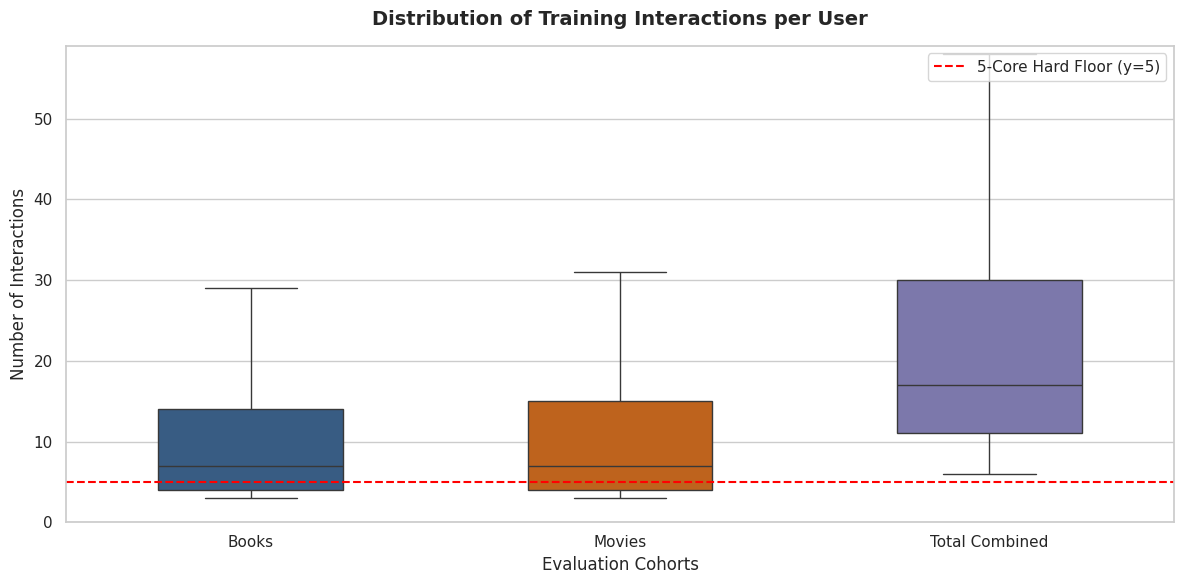


=== Quantile Distribution Summary ===
               Books         Movies  Total Combined
count  127188.000000  127188.000000   127188.000000
mean       14.649417      14.840889       29.490306
std        35.549410      33.780021       53.838036
min         3.000000       3.000000        6.000000
25%         4.000000       4.000000       11.000000
50%         7.000000       7.000000       17.000000
75%        14.000000      15.000000       30.000000
90%        28.000000      30.000000       55.000000
95%        44.000000      46.000000       84.000000
max      3132.000000    3077.000000     3407.000000


In [11]:
# 1. Calculate interaction counts per user directly from your loaded sources
user_books_counts = books_train.groupby('user_id').size().rename('Books')
user_movies_counts = movies_train.groupby('user_id').size().rename('Movies')

# For the total combined, we align them on user_id and sum them up
# fillna(0) ensures users with missing cross-domain match records don't break the sum
plot_df = pd.concat([user_books_counts, user_movies_counts], axis=1).fillna(0)
plot_df['Total Combined'] = plot_df['Books'] + plot_df['Movies']

# 2. Setup the matplotlib figure environment
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 3. Create the boxplot (showfliers=False hides extreme outliers so the box shapes are readable)
ax = sns.boxplot(
    data=plot_df[['Books', 'Movies', 'Total Combined']],
    palette=['#2b5c8f', '#d95f02', '#7570b3'],
    showfliers=False,
    width=0.5
)

# 4. Add the horizontal line marking the 5-Core structural minimum baseline
plt.axhline(y=5, color='red', linestyle='--', linewidth=1.5, label='5-Core Hard Floor (y=5)')

# 5. Customize presentation labels and layout
plt.title('Distribution of Training Interactions per User', fontsize=14, pad=15, fontweight='bold')
plt.ylabel('Number of Interactions', fontsize=12)
plt.xlabel('Evaluation Cohorts', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Dynamic y-axis scaling to show a clean view of the boxes
max_y = int(plot_df[['Books', 'Movies']].quantile(0.95).max() * 1.3)
plt.ylim(0, max_y)

plt.legend(loc='upper right', frameon=True)
plt.tight_layout()

# 6. Render chart and output summary statistics for your slides
plt.show()

print("\n=== Quantile Distribution Summary ===")
print(plot_df[['Books', 'Movies', 'Total Combined']].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95]))

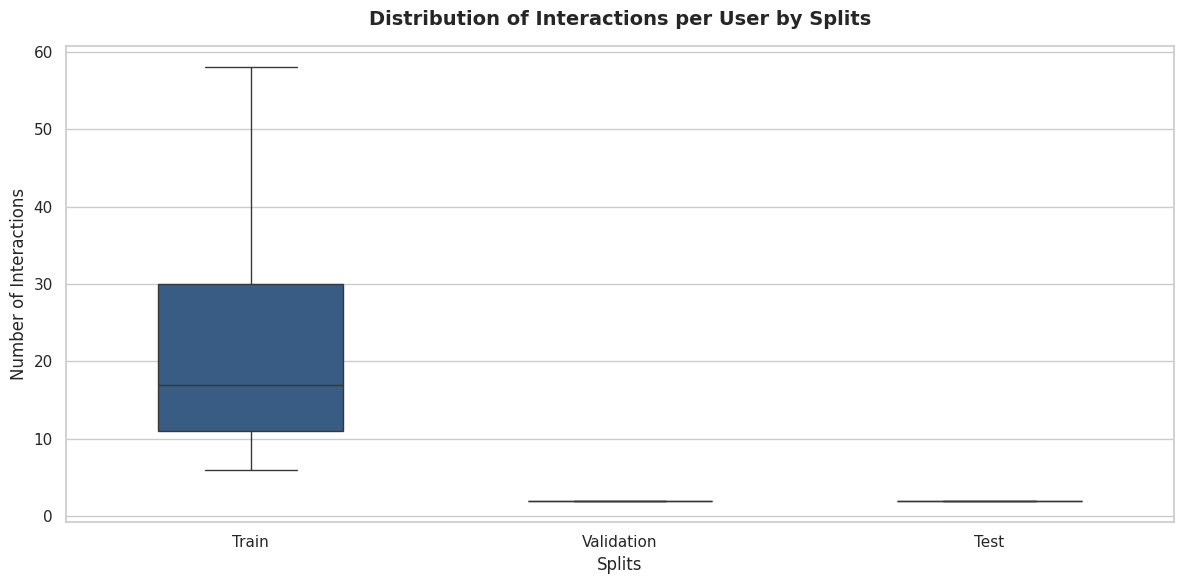

In [16]:
# 1. Calculate interaction counts per user directly from your loaded sources
plot_train = pd.concat([books_train, movies_train], axis=0)
plot_val = pd.concat([books_valid, movies_valid], axis=0)
plot_test = pd.concat([books_test, movies_test], axis=0)

plot_train_counts = plot_train.groupby('user_id').size().rename('Train')
plot_val_counts = plot_val.groupby('user_id').size().rename('Validation')
plot_test_counts = plot_test.groupby('user_id').size().rename('Test')

# For the total combined, we align them on user_id and sum them up
# fillna(0) ensures users with missing cross-domain match records don't break the sum
plot_df_train_val = pd.concat([plot_train_counts, plot_val_counts], axis=1).fillna(0)
plot_df = pd.concat([plot_df_train_val, plot_test_counts], axis=1).fillna(0)

# 2. Setup the matplotlib figure environment
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 3. Create the boxplot (showfliers=False hides extreme outliers so the box shapes are readable)
ax = sns.boxplot(
    data=plot_df[['Train', 'Validation', 'Test']],
    palette=['#2b5c8f', '#d95f02', '#7570b3'],
    showfliers=False,
    width=0.5
)

# 4. Add the horizontal line marking the 5-Core structural minimum baseline
# plt.axhline(y=5, color='red', linestyle='--', linewidth=1.5, label='5-Core Hard Floor (y=5)')

# 5. Customize presentation labels and layout
plt.title('Distribution of Interactions per User by Splits', fontsize=14, pad=15, fontweight='bold')
plt.ylabel('Number of Interactions', fontsize=12)
plt.xlabel('Splits', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Dynamic y-axis scaling to show a clean view of the boxes
# max_y = int(plot_df[['Train', 'Validation', 'Test']].quantile(0.95).max() * 1.3)
# plt.ylim(0, max_y)

plt.tight_layout()

# 6. Render chart and output summary statistics for your slides
plt.show()